In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PROBLEM FORMULATION.

We consider regression problem with likelihood function
and assume noisy variance is known
so
$$ p(y|x ,\theta )=N(y|x^T \theta, \sigma^2), ⇐⇒\begin{multline*}y=x^{T}\theta\;+\;\epsilon,\;\epsilon\;\sim\;N\left(0,\sigma^2\right)\\ \end{multline*}$$
suppose D:={ ($x_1,y_1$),($x_2,y_2$),($x_3,y_3$), , ,   ,  ,($x_n,y_n$)} are given training sets
$$\prod^N_{n=1} p(y_n|x_n ,\theta )=\prod^N_{n=1} N(y_n|x_n^T \theta, \sigma^2)$$

we solve for the $\theta$ $$\theta=arg\space max\space p(y|x ,\theta )$$
$$-\log{\prod^N_{n=1} p(y_n|x_n ,\theta )}=-log{\sum^N_{n=1} p(y_n|x_n ,\theta )}$$
$$\log p(y_n|x_n ,\theta )=-\frac{1}{2\sigma^2}(y_n-x_n^T\theta)^2 +constant$$
constant terms are independent of the $\theta$ so we ingonre them.
Using negative log-likelihood $$\mathcal{L(\theta)}:=\frac{1}{2\sigma^2}\sum^N_{n=1}(y_n-x_n^T\theta)^2
=\frac{1}{2\sigma^2}||y_n-x_n^T\theta||^2$$
Computing gardient of the $\mathcal{L}$ with respect to $\theta$
$$\frac{d\mathcal{L}}{d\theta}=\frac{1}{\sigma^2}(-y^TX+\theta^TX^TX)$$
solve for the $\theta$ by  using $\frac{d\mathcal{L}}{d\theta}=0^T$
 we get $$\theta=(X^TX)^{-1}X^Ty$$
Remark. The maximum likelihood solution  requires us to solve a system of linear equations of the form Aθ = b with A =$X^TX \space and \space b=X^Ty$

 Setting the gradient to 0⊤ is a necessary and sufficient condition,
 and we obtain a global minimum.
belwo  we will see the implementation of the above formula.

 

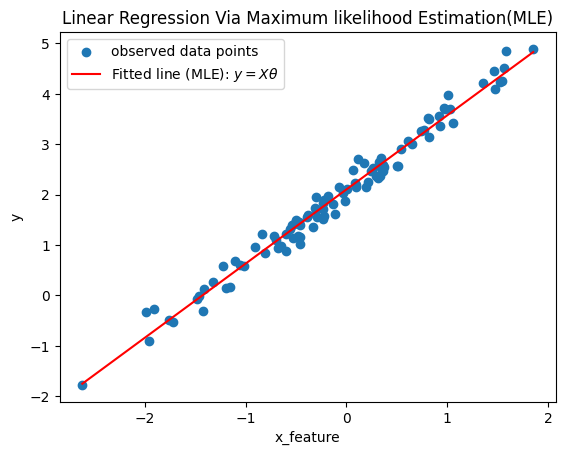

True value of parameters : [2.1 1.5]
Estimated value of  parameters via MLE: [2.10148557 1.47134857]


In [39]:
#The implementation of the maximum likelihood to estimate parameters 
np.random.seed(42)
#size of the sample points 
N=100
#randomly generated single features with N
x_feature=np.random.randn(N)

#add X_0 columns to X :-designing matrix (N,2) -
X=np.c_[np.ones(N),x_feature]
#noisy standard deviations(std) - std
sigma_mle=0.2

# intercept and slope values:- parameters value
theta_true=np.array([2.10, 1.5])#intercept=2.10, slope=1.50
#guassian noisy : mean is zero 
epsilon=np.random.normal(0,sigma_mle,size=N)

#y:= mx+b is linear regression 
y=X@theta_true + epsilon 
# MLE: solve (X^T X) theta = X^T y
A=X.T@X
b=X.T@y
#0_MLE:=(A^-1)bc- estimating theta by MLE
theta_mle=np.linalg.solve(A,b)
#dense grid
xx_feature=np.linspace(x_feature.min(),x_feature.max(),100)
XX=np.c_[np.ones(len(xx_feature)),xx_feature]
#predicted values of the y by using 0_MLE
y_hat=XX@theta_mle
#plot for visualizing:
plt.plot(figsize=(8,6))
plt.scatter(x_feature,y,label='observed data points')
plt.plot(xx_feature,y_hat,'r',label=r'Fitted line (MLE): $y = X\theta $')
plt.xlabel('x_feature')
plt.ylabel('y')
plt.title('Linear Regression Via Maximum likelihood Estimation(MLE)')
plt.legend()
plt.show()
print(f'True value of parameters : {theta_true}\nEstimated value of  parameters via MLE: {theta_mle}')

# Maximum likelihood Estimation with Features
- Linear Regression refers to Linear  in parameters in regression models but The inputs can undergo any nonlinear transformation,
for example polynomial functions.
So we do have 
$$ p(y\mid x,\theta)=\mathcal{N}\!\big(y\mid \phi(x)^T\theta, \, \sigma^2 \big)$$where $\phi$ is nonlinear transformation


We consider training inputs
$$ x_n\in \mathbb{R^D}\,\,,\,\, \,y_n \in \mathbb{R}, \quad n =1,\dots N ,$$  and define the features matrix (design matrix).

$$
\Phi =
\begin{bmatrix}
\phi_0(x_1)&\dots&\phi_{k-1}(x_1)\\
\phi_0(x_2)&\dots&\phi_{k-1}(x_2)\\
\vdots&\dots&\vdots\\
\phi_0(x_N)  &\dots&\phi_{k-1}(x_N)
\end{bmatrix}
$$
so , the maximum likelihood solution is:
$$
\theta_{ML} = (\Phi^T\Phi)^{-1}\Phi^Ty
$$

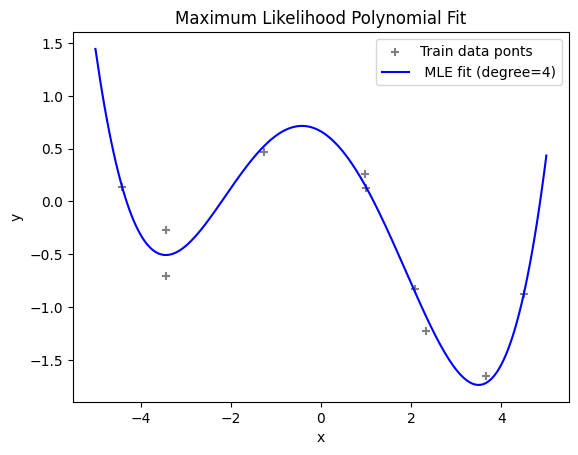

In [41]:
#implementation of Maximum likelihood Estimation with Features
#consider data set consists of N=10 pairs(x_n,y_n),
#where x_n∼U[−5,5]and y_n=−sin(x_n/5)+cos(x_n)+ϵ,where ϵ∼N(0,0.22) 

#
np.random.seed(42)
#polynomial degree  to fit
degre=4
#size of samples N

N=10
#x_n∼U[−5,5] -sample training from uniform distribution
x_n=np.random.uniform(-5,5,N)
#std
sigma_ml=0.2
#gaussian noisy with mean is zero
epsilon=np.random.normal(0,sigma_ml,size=N)
#y_n=−sin(x_n/5)+cos(x_n)+ϵ->target
y_n=-np.sin(x_n/5)+np.cos(x_n) + epsilon
#design matrix of degree of polynomial: [1,x_n]-degree-1, ---[1,x_n,x_n*x_n,,,,x_n^4]-degree-4
phi=np.vstack([x_n**i for i in range (degre +1)]).T#design matrix with size (10,5)
#theta_MLe:-- A0_ml=b
A=phi.T@phi
b=phi.T@y_n
theta_ml=np.linalg.solve(A,b)

#plotting dense-grid
#evenly spaced points->new data points
xx=np.linspace(-5,5,200)

phi_xx=np.vstack([xx**i for i in range(degre+1)]).T

y_xx=phi_xx@theta_ml

plt.plot(figsize=(8,6));
plt.scatter(x_n,y_n,color='gray',marker='+',label ='Train data ponts');
plt.plot(xx,y_xx,'b',label=' MLE fit (degree=4)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Maximum Likelihood Polynomial Fit')
plt.legend()
plt.show()

# Estimating the Noise Variance

- Thus far, we assumed that the noise variance $\sigma^2$ is known.However, we can also use the principle of maximum likelihood estimation to obtain the maximum likelihood estimator $\sigma_{\text{ML}}^2$ for the noise variance.  To do this, we follow the standard procedure: we write down the log-likelihood,  compute its derivative with respect to $\sigma_{\text{ML}}^2$, with $\sigma_{\text{ML}}^2 > 0$,  
then set it to 0 and solve

$$
\log p(\mathcal{Y}\mid \mathcal{X},\theta,\sigma^2)=\sum_{n=1}^N{\log \mathcal{N(\mathcal{y_n}\mid \phi^T(\mathcal{x_n}) \theta,\sigma^2)}}
$$

$$
= -\frac{N}{2}\log \sigma^2 -\frac{1}{2\sigma^2}\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2 +\text{constant}
$$
$$
\text{s}=\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2
$$
$$
\frac{\partial \log p(\mathcal{Y}\mid \mathcal{X},\theta,\sigma^2)}{\partial \sigma^2}=-\frac{N}{2\sigma^2} + \frac{1}{2\sigma^4}= 0,
\iff \frac{N}{2\sigma^2}=\frac{s}{2\sigma^4}
$$
  so that
  $$
  \sigma_{\text{ML}}^2=\frac{s}{N}=\frac{1}{N}\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2
  $$
  the maximum likelihood estimate of the noise variance is the
 empirical mean of the squared distances between the noise-free function
 value$\phi^T(\mathcal{x_n}) \theta$ and the corresponding noisy observations $y_n$ at input 
 locations $x_n$.  


n.

# Overfitting In Linear Regression 
- We can evaluate the quality of
 the model by computing the error/loss incurred, We ofen use the Root means square Error(RMSE) to evaluate the mdoel
- RMSE: allows us to compare errors of datasets with different sizes  and has the same scale and the same unit as the observed function values.

$$
  \sqrt{\frac{1}{N} \|{\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)\|^2}}=\sqrt{\frac{1}{N}\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2},
$$


For model selection , we can use the RMSE 
(or the  negative log-likelihood) to determine the best degree of the polynomial byfinding the polynomial degree M that minimizes the object function
ive